# Machine Learning Fundamentals: Classification with scikit-learn (Phoneme Dataset)

In this notebook, we will explore **classification** using Python's **scikit-learn** library.

## Learning objectives

By the end of this notebook, you will be able to:
- Load a classification dataset and identify features vs. labels (classes)
- Visualize the feature space with a seaborn pair plot
- Split data into train/test sets safely
- Fit and evaluate multiple classifiers
- Compare classifiers using metrics and confusion matrices

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

print("Imports ready.")

Imports ready.


## 1. Load and explore the dataset

We will use the [**Phoneme**](https://www.openml.org/search?type=data&status=active&id=1489) dataset (via OpenML). The aim of this dataset is to distinguish between nasal (class 1) and oral sounds (class 2). Five different attributes were chosen to characterize each vowel: they are the amplitudes of the five first harmonics, normalised by the total energy.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- How many samples and how many features do we have?
- Look at the feature values, do they need to be scaled? (Hint: look at the mean and standard deviation)
</div>

In [ ]:
# Fetch dataset from OpenML (requires internet the first time; afterwards it may be cached)
phoneme = fetch_openml(name="phoneme", version=1, as_frame=True)
df_full = phoneme.frame.copy()

target_col = phoneme.target_names[0]  # usually 'class'

# Separate features and target
X_df = df_full.drop(columns=[target_col])
y_raw = df_full[target_col].astype(str)

# Create stable class order and map to 0/1
class_names = ['nasal', 'oral']
y = pd.Categorical(y_raw, categories=['1', '2']).codes

X = X_df.to_numpy()
feature_names = list(X_df.columns)

print(f"X shape: {X.shape} | y shape: {y.shape}")
print("Features:", feature_names)
print("Classes:", class_names)

# Combine into one DataFrame for plotting
df = X_df.copy()
df["class_id"] = y
df["class_name"] = [class_names[i] for i in y]

df.head()

X shape: (5404, 5) | y shape: (5404,)
Features: ['V1', 'V2', 'V3', 'V4', 'V5']
Classes: ['nasal', 'oral']


,V1,V2,V3,V4,V5,class_id,class_name
0,0.489927,-0.451528,-1.047990,-0.598693,-0.020418,0,nasal
1,-0.641265,0.109245,0.292130,-0.916804,0.240223,0,nasal
2,0.870593,-0.459862,0.578159,0.806634,0.835248,0,nasal
3,-0.628439,-0.316284,1.934295,-1.427099,-0.136583,0,nasal
4,-0.596399,0.015938,2.043206,-1.688448,-0.948127,0,nasal


Let's check the **class balance** (how many samples there are per class).

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Are the classes balanced?
- Why can class imbalance make evaluation metrics like accuracy misleading?
</div>

In [91]:
df["class_name"].value_counts()

class_name
nasal    3818
oral     1586
Name: count, dtype: int64

## 2. Visualize the feature space (pair plot)

Here we will use a **pair plot** to helps us see how well classes separate in different feature combinations.

A pair plot (also called scatterplot matrix) is a grid of plots that shows pairwise combinations between multiple variables in a dataset, all at once. In this grid, each row and column represents a variable. The off-diagonal cells show a scatter plot of one variable against another. These can help to find patterns like correlations, clusters or groupings, outliers, or nonlinear relationships between the features. The diagonal cells show the distribution of each variable (with a histogram or a KDE curve).

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Which relationships do you see between the features?
- Are the two classes clearly separated?
- Do you expect a linear classifier to work well here?
</div>

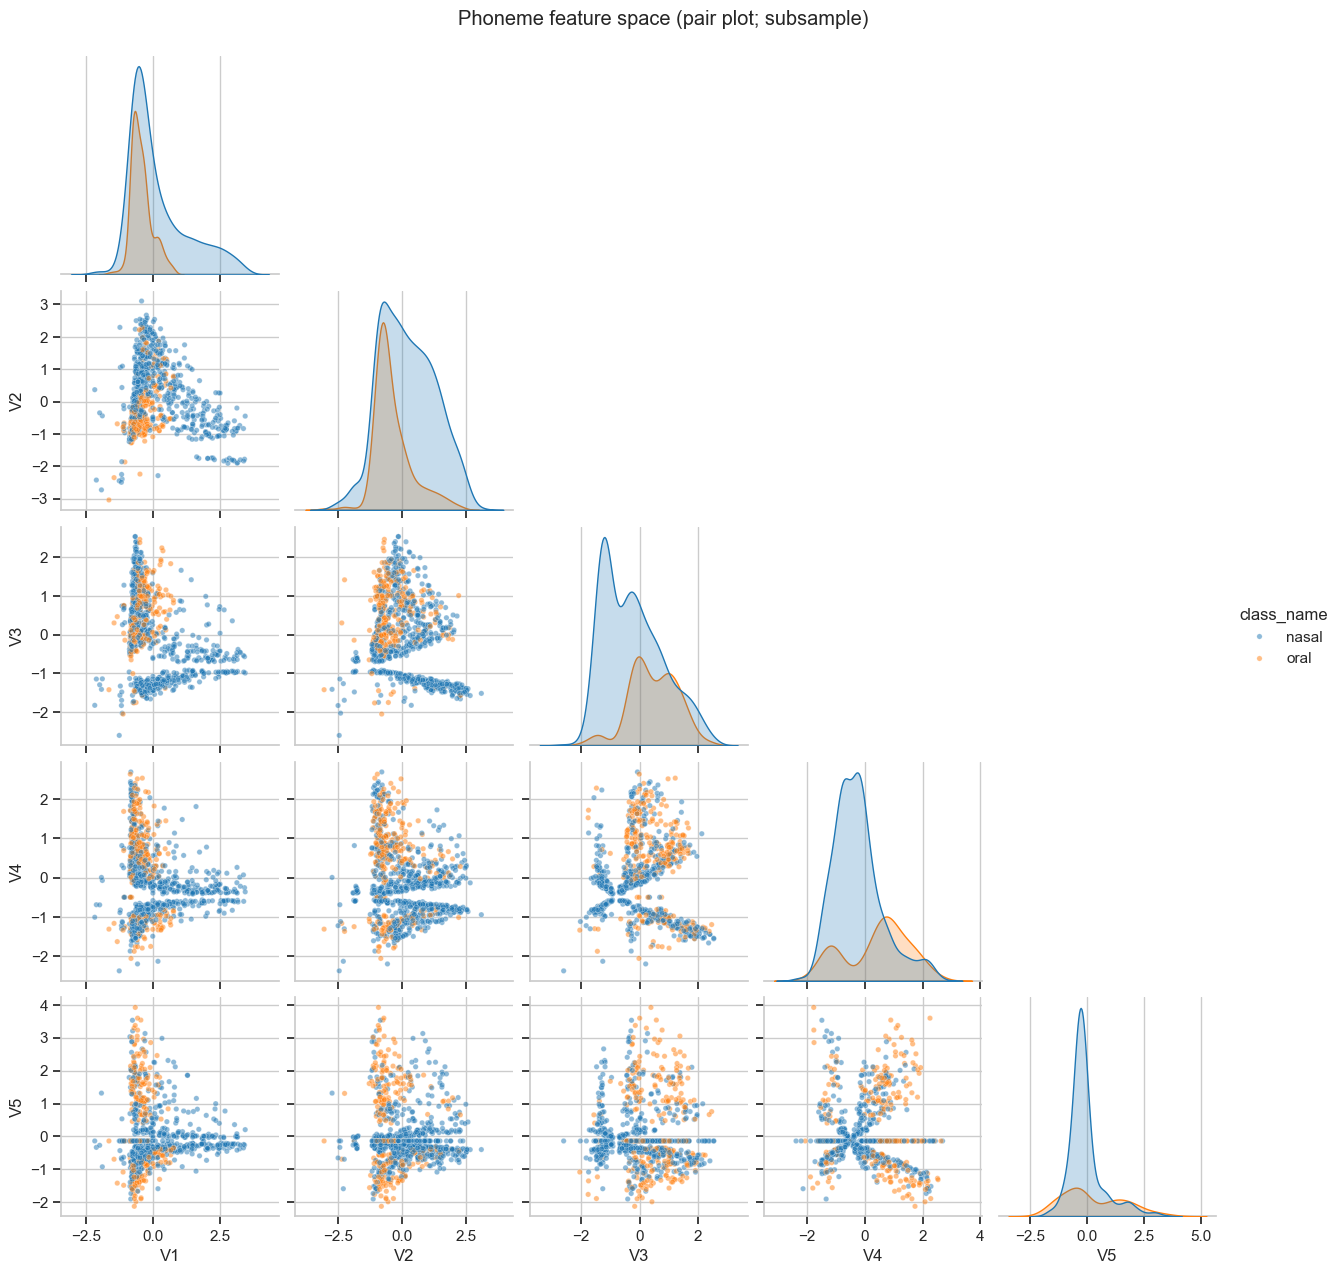

In [94]:
# Choose the first 5 features for a readable pair plot
pairplot_features = feature_names[:5]

# Subsample for speed (pair plots can be slow with many points)
df_plot = df.sample(n=min(1000, len(df)), random_state=42)

sns.pairplot(
    df_plot,
    vars=pairplot_features,
    hue="class_name",
    corner=True,
    plot_kws={"alpha": 0.5, "s": 15}
)
plt.suptitle("Phoneme feature space (pair plot; subsample)", y=1.02)
plt.show()

## 3. Train/test split

We split data into a **training set** (to fit models) and a **test set** (to evaluate once).

We use `stratify=y` so each class is represented similarly in train and test.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why do we need a separate test set?
- What could go wrong if we evaluate on the same data we train on?
- What does `stratify=y` do?
</div>

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 4323
Test size: 1081


## 4. Feature scaling (important for some classifiers)

Some models (like **Logistic Regression** and **SVM**) are sensitive to the scale of features.
Tree-based models (Decision Tree, Random Forest) typically do **not** need scaling.

Luckily for us, the features in the dataset from openML were already scaled. However, we will still add a scaling step for good practice.

Important: we **fit** the scaler on training data only, then **transform** test data.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why do we use `fit_transform` on training data but only `transform` on test data?
- What is data leakage?
</div>

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Quick sanity check: training features should be ~0 mean and ~1 std after scaling
print("Mean (train, scaled):", np.round(X_train_scaled.mean(axis=0), 3))
print("Std  (train, scaled):", np.round(X_train_scaled.std(axis=0), 3))

Mean (train, scaled): [ 0.  0.  0. -0.  0.]
Std  (train, scaled): [1. 1. 1. 1. 1.]


## 5. Logistic Regression

We will start with Logistic Regression which is a strong baseline classifier. It is ideally suited for linearly separable datasets and can give surprisingly good performance even for complex classification problems.

Logistic Regression is a popular model in classical machine learning because it is simple to train, has good interpretability, and gives a probabilistic output. The latter gives it a great advantage in domains where uncertainty quantification is important (e.g. in medical domains, where we might prefer the predictions to be expressed as a percentage instead of a binary yes-no answer).

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- If train accuracy is much higher than test accuracy, what might be happening?
- How do you explain the difference between the accuracy and balanced accuracy?
</div>

In [99]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the (scaled) training data
log_reg.fit(X_train_scaled, y_train)

# Evaluate the trained model
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

print("Training set evaluation:")
acc = accuracy_score(y_train, y_train_pred)
bal_acc = balanced_accuracy_score(y_train, y_train_pred)
print(f"  Accuracy:          {acc:.4f}")
print(f"  Balanced accuracy: {bal_acc:.4f}")

print("\nTest set evaluation:")
acc = accuracy_score(y_test, y_test_pred)
bal_acc = balanced_accuracy_score(y_test, y_test_pred)
print(f"  Accuracy:          {acc:.4f}")
print(f"  Balanced accuracy: {bal_acc:.4f}")

Training set evaluation:
  Accuracy:          0.7546
  Balanced accuracy: 0.6748

Test set evaluation:
  Accuracy:          0.7364
  Balanced accuracy: 0.6455


#### Quick and easy evaluation metrics
Instead of computing all performance metrics separately, we can also use the [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) function from scikit-learn to get a quick overview of how well the model is doing.

[Confusion matrices]() provide another quick insight into the predictions of the model. They are very popular in scientific reporting because they are visually intuitive and give a complete overview of all the correct and incorrect predictions.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Do you see any patterns in the performance metrics?
- Is the model better at predicting one class and worse at the other?
</div>

In [111]:
# Classification report
print("Classification report (Test):")
print(classification_report(y_test, y_test_pred, target_names=class_names))

Classification report (Test):
              precision    recall  f1-score   support

       nasal       0.78      0.87      0.82       764
        oral       0.57      0.43      0.49       317

    accuracy                           0.74      1081
   macro avg       0.68      0.65      0.65      1081
weighted avg       0.72      0.74      0.72      1081



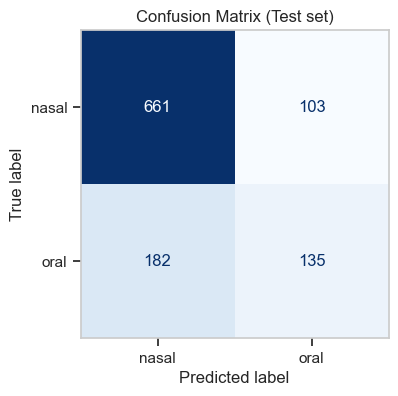

In [125]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(4, 4))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, colorbar=False, ax=ax)
plt.grid(False)
plt.title("Confusion Matrix (Test set)")
plt.show()

## 6. A helper function to evaluate classifiers

To keep the notebook readable, we use a helper function that:
- Fits the model
- Computes train/test accuracy and balanced accuracy
- Prints a classification report (precision/recall/F1)
- Plots a confusion matrix

We will use the same evaluation for all models so comparisons are fair.

Logistic Regression
Train accuracy: 0.755 | Test accuracy: 0.736
Train balanced acc: 0.675 | Test balanced acc: 0.646

Classification report (Test):
              precision    recall  f1-score   support

       nasal       0.78      0.87      0.82       764
        oral       0.57      0.43      0.49       317

    accuracy                           0.74      1081
   macro avg       0.68      0.65      0.65      1081
weighted avg       0.72      0.74      0.72      1081



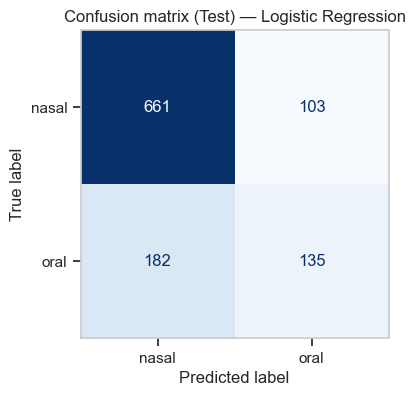

In [127]:
def evaluate_classifier(model, X_tr, X_te, y_tr, y_te, title, class_names):
    """Fit a classifier, print metrics, plot confusion matrix, and return a summary row."""
    model.fit(X_tr, y_tr)

    # Make predictions on training and test data
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    # Compute the accuracy, balanced accuracy, and print classification report
    acc_tr = accuracy_score(y_tr, pred_tr)
    acc_te = accuracy_score(y_te, pred_te)
    bacc_tr = balanced_accuracy_score(y_tr, pred_tr)
    bacc_te = balanced_accuracy_score(y_te, pred_te)

    print(title)
    print(f"Train accuracy: {acc_tr:.3f} | Test accuracy: {acc_te:.3f}")
    print(f"Train balanced acc: {bacc_tr:.3f} | Test balanced acc: {bacc_te:.3f}")
    print()
    print("Classification report (Test):")
    print(classification_report(y_te, pred_te, target_names=class_names))

    # Plot the confusion matrix (test set)
    fig, ax = plt.subplots(figsize=(4, 4))
    cm = confusion_matrix(y_te, pred_te)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", values_format="d", colorbar=False, ax=ax)
    plt.grid(False)
    plt.title(f"Confusion matrix (Test) — {title}")
    plt.show()

    return {
        "model": title,
        "train_accuracy": acc_tr,
        "test_accuracy": acc_te,
        "train_balanced_accuracy": bacc_tr,
        "test_balanced_accuracy": bacc_te,
    }

res_lr = evaluate_classifier(
    log_reg,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    title="Logistic Regression",
    class_names=class_names
    )

## 7. Support Vector Machine (SVM)

Next we will use an SVM with an RBF kernel, which will allow the SVM to model non-linear relationships.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Does SVM perform better or worse than Logistic Regression here?
- Why might a non-linear kernel help?
- Can you try to use a different kernel? How does it affect the performance? (Hint: look at the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) to see which kernels are supported)
</div>

SVM (RBF kernel, scaled features)
Train accuracy: 0.856 | Test accuracy: 0.833
Train balanced acc: 0.823 | Test balanced acc: 0.794

Classification report (Test):
              precision    recall  f1-score   support

       nasal       0.88      0.89      0.88       764
        oral       0.72      0.70      0.71       317

    accuracy                           0.83      1081
   macro avg       0.80      0.79      0.80      1081
weighted avg       0.83      0.83      0.83      1081



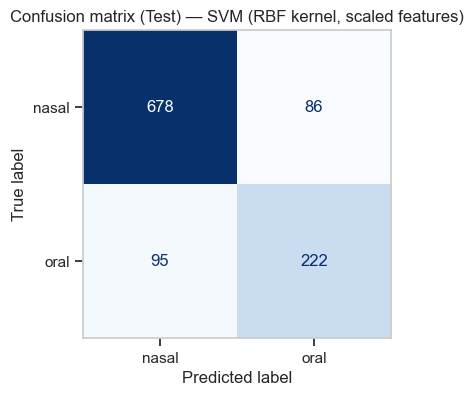

In [133]:
svm = SVC(kernel="rbf", gamma="scale", C=1.0, random_state=42)

res_svm = evaluate_classifier(
    svm,
    X_train_scaled, X_test_scaled,
    y_train, y_test,
    title="SVM (RBF kernel, scaled features)",
    class_names=class_names
)

## 8. Decision Tree

Decision trees can learn non-linear decision boundaries and do **not** require scaling. They also have a very intuitive prediction pattern with a series of sequential splitting decisions. This makes decision trees ideal for cases where you want to have clear interpretability and traceability of why certain predictions were made. For more complex classification problems and large numbers of features the decision tree can however quickly become too large and lose their interpretability.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Do trees overfit easily?
- What might happen if we let a tree grow without limits?
</div>

Decision Tree (no scaling)
Train accuracy: 1.000 | Test accuracy: 0.841
Train balanced acc: 1.000 | Test balanced acc: 0.803

Classification report (Test):
              precision    recall  f1-score   support

       nasal       0.88      0.90      0.89       764
        oral       0.74      0.71      0.72       317

    accuracy                           0.84      1081
   macro avg       0.81      0.80      0.81      1081
weighted avg       0.84      0.84      0.84      1081



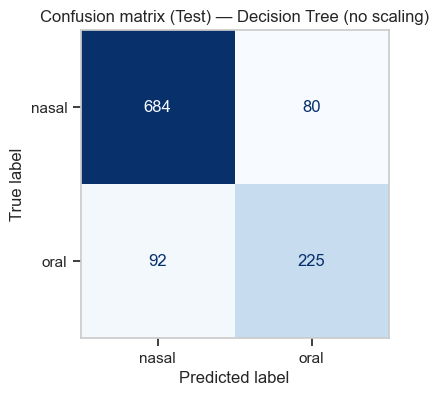

In [ ]:
tree = DecisionTreeClassifier(random_state=42)

res_tree = evaluate_classifier(
    tree,
    X_train, X_test,
    y_train, y_test,
    title="Decision Tree",
    class_names=class_names
)

Now let's take a look at the structure of the decision tree and how predictions are made.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Does this provide a clear and intuitive overview of the decision tree model?
- How could we improve the interpretability of the model?
</div>

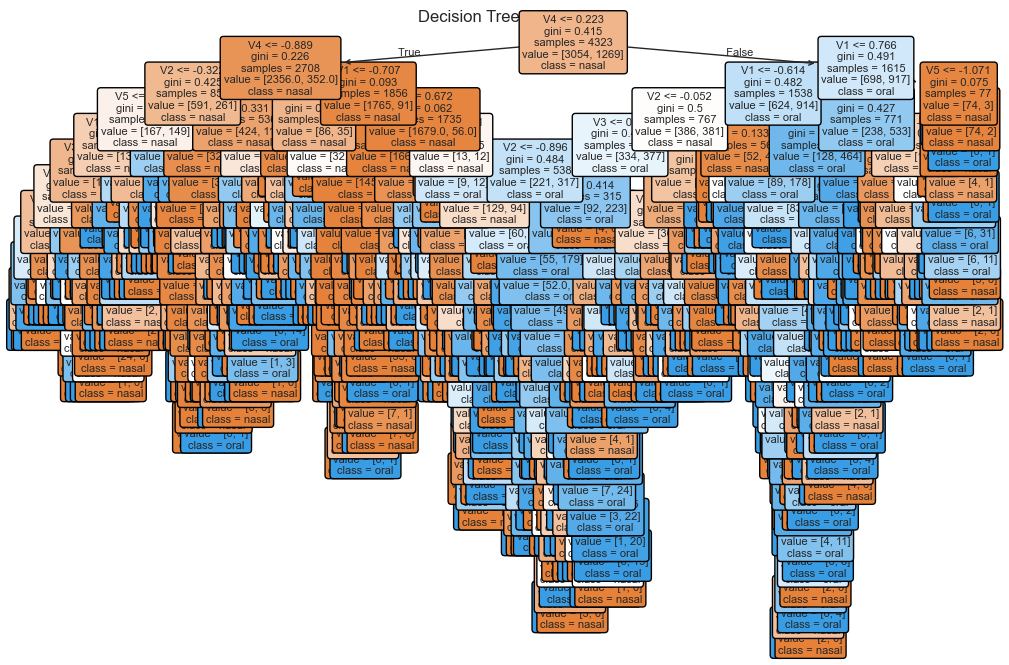

In [142]:
from sklearn.tree import plot_tree
fig, ax = plt.subplots(figsize=(12, 8))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
plt.title("Decision Tree Structure")
plt.show()

## 9. Random Forest

Random forests are ensembles of decision trees and often generalize better than a single tree.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why might random forest generalize better than a single decision tree?
- Do you expect training accuracy to be very high for a random forest?
</div>

Random Forest (no scaling)
Train accuracy: 1.000 | Test accuracy: 0.905
Train balanced acc: 1.000 | Test balanced acc: 0.876

Classification report (Test):
              precision    recall  f1-score   support

       nasal       0.92      0.95      0.93       764
        oral       0.86      0.81      0.83       317

    accuracy                           0.90      1081
   macro avg       0.89      0.88      0.88      1081
weighted avg       0.90      0.90      0.90      1081



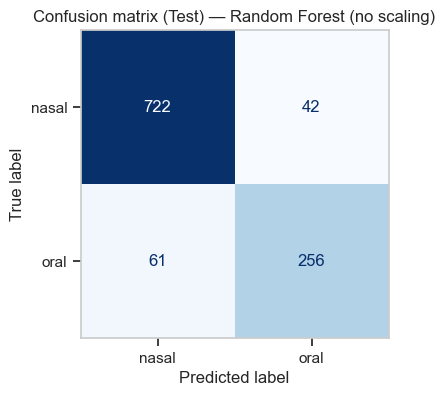

In [ ]:
forest = RandomForestClassifier(n_estimators=200, random_state=42)

res_forest = evaluate_classifier(
    forest,
    X_train, X_test,
    y_train, y_test,
    title="Random Forest",
    class_names=class_names
)

## 10. Compare model performance

We put key metrics into a table to compare models quickly.

Tip: If models look very similar, use the confusion matrices to understand *which mistakes* are made.

In [145]:
results = pd.DataFrame([res_lr, res_svm, res_tree, res_forest]).set_index("model")
results.sort_values("test_accuracy", ascending=False)

,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy
model,,,,
Random Forest (no scaling),1.000000,0.904718,1.000000,0.876299
Decision Tree (no scaling),1.000000,0.840888,1.000000,0.802534
"SVM (RBF kernel, scaled features)",0.855656,0.832562,0.823455,0.793875
Logistic Regression,0.754569,0.736355,0.674762,0.645525


## 11. Wrap-up

In this notebook you:
- Visualized class separation with a pair plot
- Trained and evaluated four common classifiers
- Compared results using metrics and confusion matrices

Next session we will learn how to tune models more systematically (cross-validation, pipelines, and hyperparameter search).

---

## Optional exercises (for early finishers)

### A. Inspect misclassified samples

Goal: identify which test samples were misclassified and look for patterns.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Which classes are most often confused?
- Are misclassified samples near overlaps you saw in the pair plot?
</div>

In [190]:
# Choose a model to inspect (try: log_reg, svm, tree, forest)
best_model = forest

pred = best_model.predict(X_test_scaled)
wrong_idx = np.where(pred != y_test)[0]
print("Number of misclassified test samples:", len(wrong_idx))

Number of misclassified test samples: 106


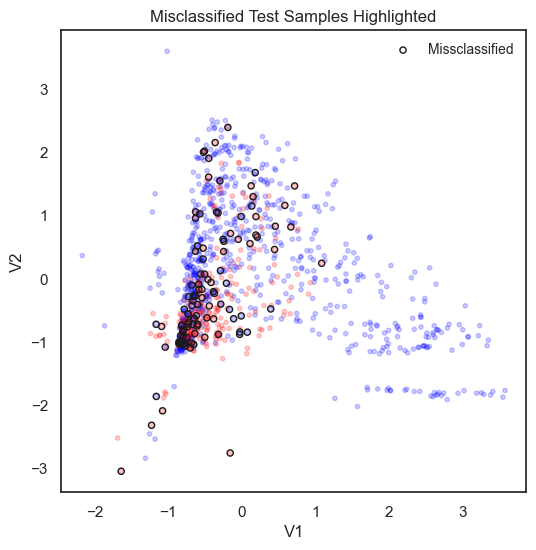

In [ ]:
feature_0 = 0
feature_1 = 1

fig, ax = plt.subplots(figsize=(6, 6))

# Plot all test points with transparency
ax.scatter(
    X_test[:, feature_0],
    X_test[:, feature_1],
    c=['blue' if label == 0 else 'red' for label in y_test],
    alpha=0.2,
    s=10
)

# Add a scatter plot of the missclassified points
# Hint: use facecolor='none' to get unfilled markers

# -------------------------------
# INSERT YOUR OWN CODE HERE
# -------------------------------

ax.set_xlabel(feature_names[feature_0])
ax.set_ylabel(feature_names[feature_1])
ax.legend(loc='upper right', fontsize='small')
plt.title("Misclassified Test Samples Highlighted")
plt.show()

### B. Manual hyperparameter sensitivity

Try changing **one** parameter manually and re-run evaluation.

Examples:
- SVM: `C` (e.g., 0.1, 1, 10)
- Decision Tree: `max_depth` (e.g., 1, 2, 3, None)
- Random Forest: `n_estimators` or `max_depth`

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Which parameter changes reduce overfitting?
- Do results change a lot, or are they stable?
</div>

Decision Tree (max_depth=3)
Train accuracy: 0.775 | Test accuracy: 0.762
Train balanced acc: 0.671 | Test balanced acc: 0.657

Classification report (Test):
              precision    recall  f1-score   support

       nasal       0.79      0.91      0.84       764
        oral       0.65      0.40      0.50       317

    accuracy                           0.76      1081
   macro avg       0.72      0.66      0.67      1081
weighted avg       0.75      0.76      0.74      1081



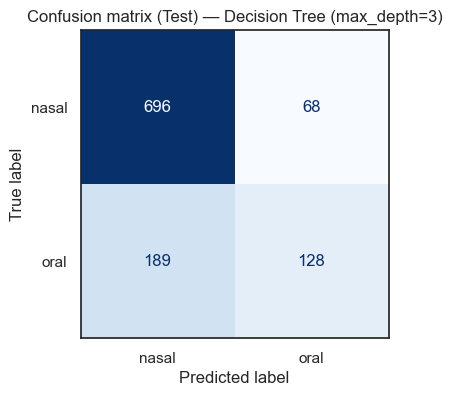

In [171]:
# Example: a shallower tree can reduce overfitting
tree_small = DecisionTreeClassifier(max_depth=3, random_state=42)

_ = evaluate_classifier(
    tree_small,
    X_train, X_test,
    y_train, y_test,
    title="Decision Tree (max_depth=3)",
    class_names=class_names
)

## C. Model evaluation: ROC curve
Next to the classification report and confusion matrix, the Receiver Operating Characteristing (ROC) curve is another popular way of visualizing the performance of a classifier. It has an associated performance metric called AUC (appropriately named so because it is defined by calculating the Area Under the Curve). The AUC is popular for comparing different models, because -contrary to the other performance metrics- it is independent of the threshold and can handle class imbalances relatively well.

Here we will plot the ROC curve for our trained models.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- How do you interpret the differences between these curves?
- If I want to deploy the Random Forest model with a specificity of 90%, what will the sensitivity be? What about the SVM model? (Hint: False Positive Rate = 1 - specificity; True Positive Rate = sensitivity)
</div>

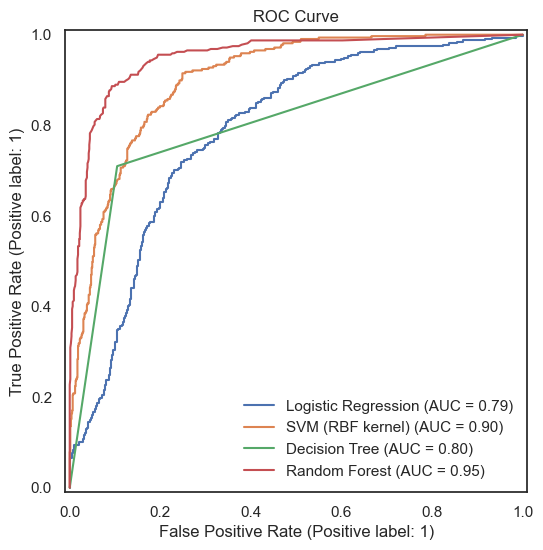

In [ ]:
from sklearn.metrics import RocCurveDisplay

# Define classifiers to evaluate
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF kernel)": SVC(kernel="rbf", gamma="scale", C=1.0, probability=True,random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

# Plot ROC curves
fig, ax = plt.subplots(figsize=(6, 6))
for name, model in classifiers.items():
    model.fit(X_train_scaled, y_train)
    y_test_pred = model.predict_proba(X_test_scaled)
    
    RocCurveDisplay.from_predictions(y_test, y_test_pred[:, 1], name=name, ax=ax)
plt.title("ROC Curve")
plt.show()

### D. Feature importance

Random forests can estimate feature importance. This can help interpretation (but it is not perfect).

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Which features seem most important?
- Do these match what you saw in the pair plot?
</div>

In [ ]:
importances = pd.Series(forest.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(6, 3))
importances[::-1].plot(kind="barh", color="#4C72B0")
plt.title("Random Forest feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

V4    0.258077
V3    0.212692
V1    0.201486
V2    0.170431
V5    0.157314
dtype: float64

Now do the same for your trained Logistic Regression model. Look at the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) to see how you can extract the coefficients from the LogisticRegression model.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Are these the same features that were important for Random Forest?
- Do you expect the feature importance to be the same for every model?
</div>

In [ ]:
# -------------------------------
# INSERT YOUR OWN CODE HERE
# -------------------------------